# Lasso — individual model deep-dive

**How these model notebooks work** (template — copy this file, change
`MODEL_NAME` below, and you have a notebook for any model):

- All numbers come from the **shared pipeline output**
  (`data/results/forecasts.parquet`, produced by `python run.py backtest`).
  We never re-fetch data or re-implement the backtest here, so the numbers
  in every notebook **agree with the official results** by construction.
- All logic lives in `src/diagnostics.py`; cells here only call it.

Prerequisite: `make all` (or at least `run.py backtest`) has been run.

In [15]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `src` importable

import pandas as pd
from src import diagnostics as dx
from src.config import DATA_PROCESSED
from src.evaluate import load_results

MODEL_NAME = 'AR1'   # <-- the ONE line to change for another model

results = load_results()
weekly = pd.read_parquet(DATA_PROCESSED / 'weekly.parquet')
results['model'].unique()

<ArrowStringArray>
['RandomWalk', 'RW+Drift', 'AR1', 'OLS', 'Ridge', 'Lasso']
Length: 6, dtype: str

## 1. Headline: how does it score, and is it significantly different from AR1?
`rmse_vs_ar1 < 1` = beats the benchmark. `dm_pvalue` small = the difference is statistically real, not luck.

In [9]:
dx.summary(results, MODEL_NAME).round(4)

,rmse,mae,hit_rate,n,rmse_vs_ar1,dm_stat_vs_ar1,dm_pvalue
model,,,,,,,
RandomWalk,0.56,0.448,NaN,261.0,1.002,0.3759,0.7073


## 2. Direction "confusion matrix"
The classification view of the forecast: did we call rand-weaker vs rand-stronger correctly over the next 4 weeks?

In [10]:
dx.direction_confusion(results, MODEL_NAME)

actual,weaker rand (USDZAR up),stronger rand (USDZAR down)
predicted,,
weaker rand (USDZAR up),0,0
stronger rand (USDZAR down),0,0


/Users/User/PersonalProjects/Hackathons/VibesFC/src/diagnostics.py:105: RuntimeWarning: invalid value encountered in scalar divide
  ax.text(j, i, f"{n}\n({n / total:.0%})", ha="center", va="center",
/Users/User/PersonalProjects/Hackathons/VibesFC/src/diagnostics.py:109: RuntimeWarning: invalid value encountered in scalar divide
  f"hit rate {correct / total:.1%} ({correct}/{total})")


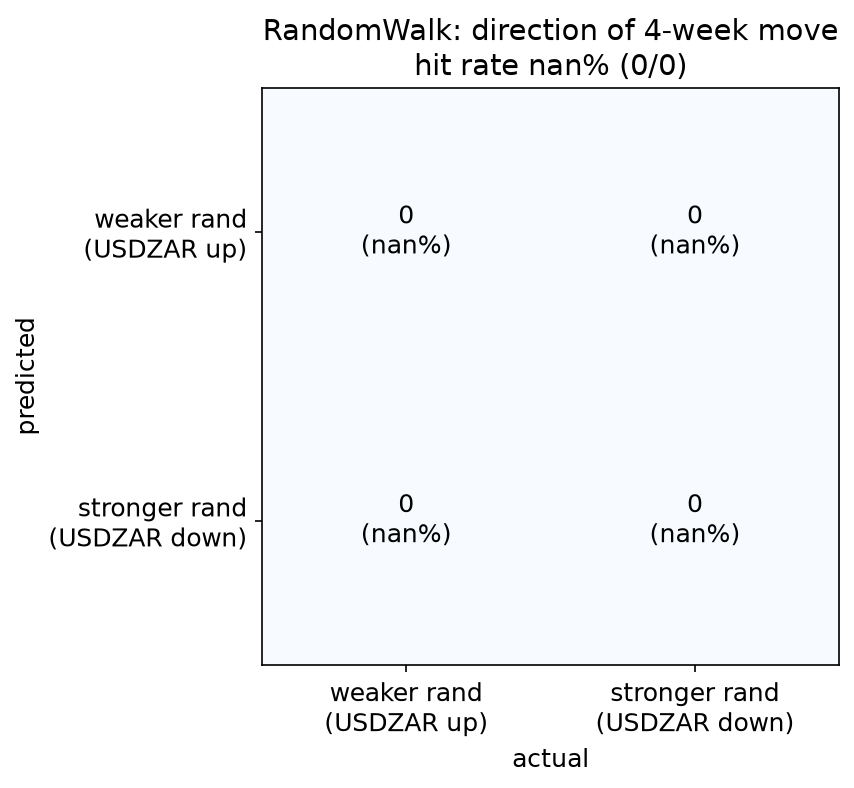

In [11]:
dx.fig_confusion(results, MODEL_NAME);

## 3. When does it win / lose vs AR1?
Per-year RMSE ratio (<1 = Lasso winning that year), then the full error timeline.

In [12]:
dx.per_year_vs_benchmark(results, MODEL_NAME).round(4)

model,AR1,RandomWalk,RandomWalk / AR1
year,,,
2021,0.5068,0.5102,1.0065
2022,0.6937,0.6928,0.9987
2023,0.6546,0.6493,0.9920
2024,0.4420,0.4449,1.0064
2025,0.4481,0.4574,1.0208


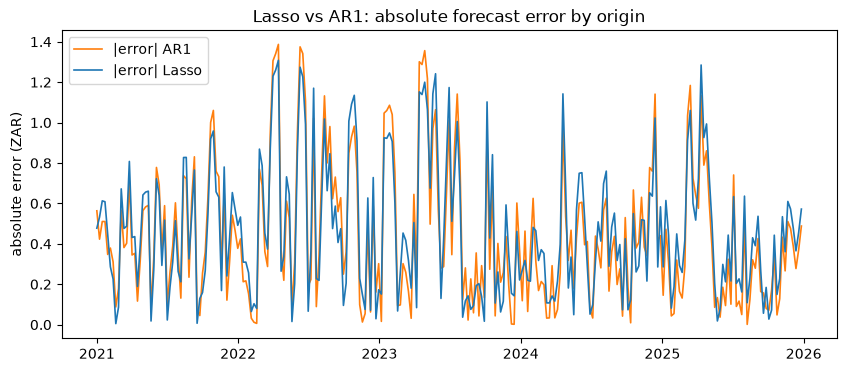

In [5]:
dx.fig_error_timeline(results, MODEL_NAME);

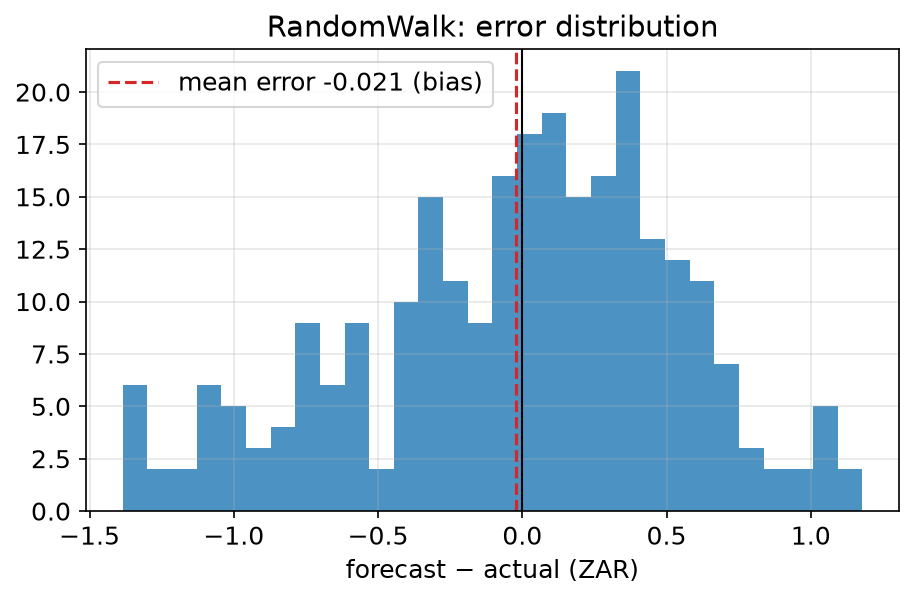

In [13]:
dx.fig_error_hist(results, MODEL_NAME);

## 4. Forecasts vs reality

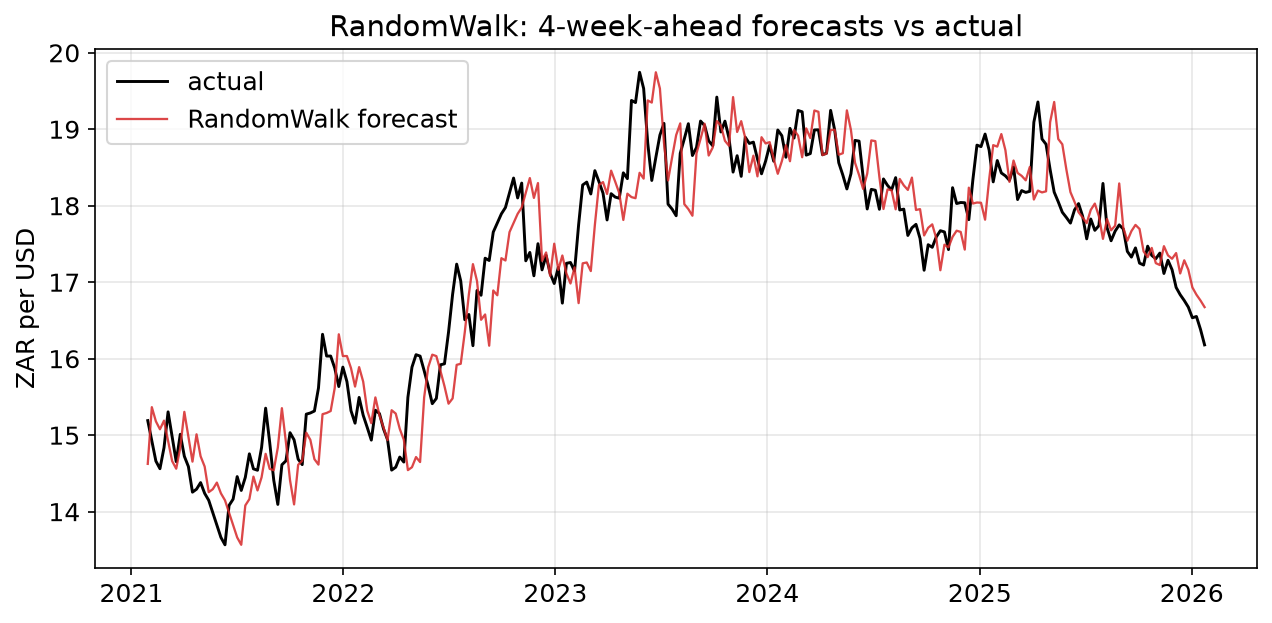

In [14]:
from src.plots import fig_forecast_vs_actual
fig_forecast_vs_actual(results, MODEL_NAME);

## 5. Lasso-specific: which features survive, and how hard does it shrink?

This is the Lasso's superpower as a *story*: it zeroes out features it finds
useless. We refit the **actual pipeline model class** at one origin per year
(same code the backtest ran) and look at the surviving coefficients and the
cross-validated alpha. Coefficients are per one standard deviation of the
feature, so sizes are comparable. A row of zeros with tiny alpha means
"in that era, Lasso decided no-change was best" — which is exactly why its
RMSE hugs the random walk in calm years.

*(~1 min to run: 6 refits, each with a small grid search. For Ridge, copy
this cell with `RidgeModel`.)*

In [9]:
from src.models.regressions import LassoModel

yearly_origins = pd.DatetimeIndex(
    [results['origin'].loc[results['origin'].dt.year == y].max() for y in range(2021, 2026)]
)
coefs = dx.linear_coefs_over_time(weekly, LassoModel, yearly_origins)
coefs.round(4)

,d4_log_gold,d4_log_brent,d4_log_dxy,d4_vix,rate_spread,mr_gap,(alpha)
2021-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0178
2022-12-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0100
2023-12-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0100
2024-12-27,0.0,0.0,0.0,0.0,0.0,0.0,0.0056
2025-12-26,0.0,0.0,0.0,0.0,0.0,0.0,0.0056


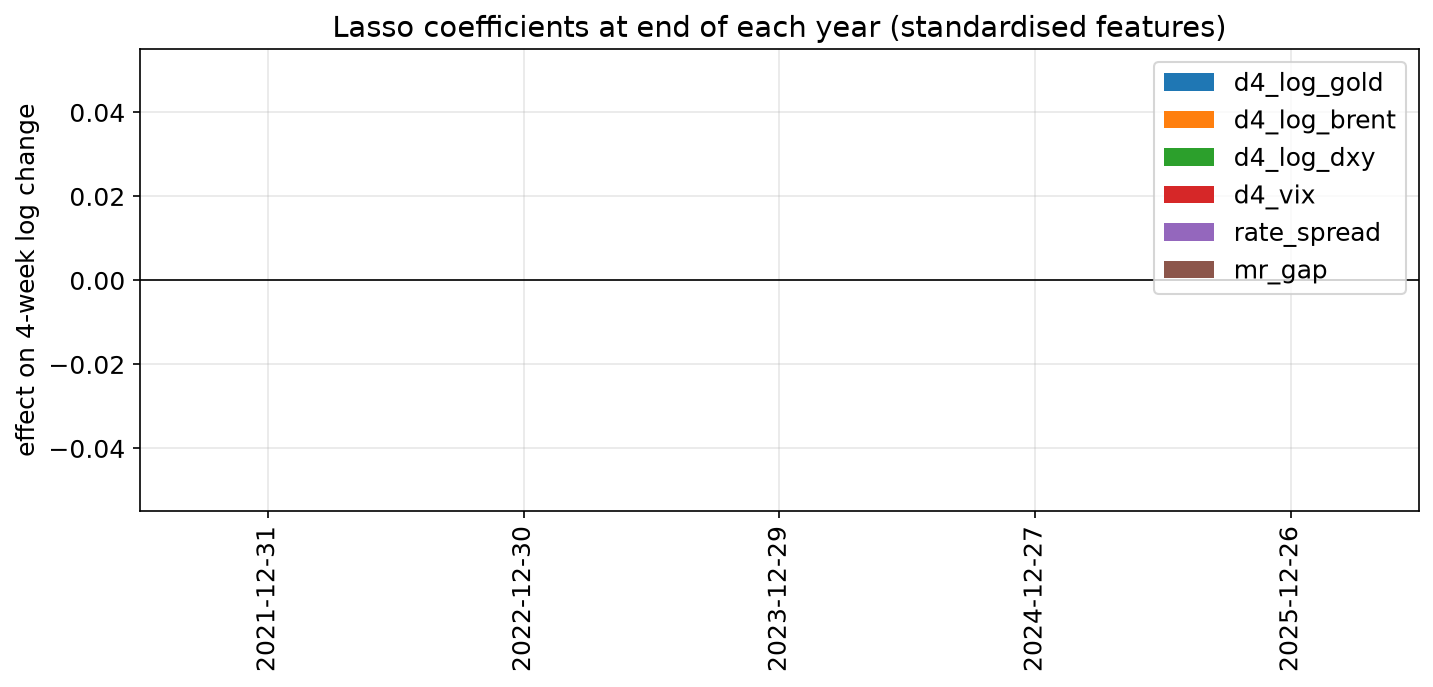

In [10]:
ax = coefs.drop(columns='(alpha)').plot(kind='bar', figsize=(11, 4))
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Lasso coefficients at end of each year (standardised features)')
ax.set_ylabel('effect on 4-week log change');

## 6. Notes / conclusions (fill in as we learn)

- ...
